In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.signal import find_peaks, convolve, medfilt, savgol_filter
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import matplotlib.animation as animation
import matplotlib as mpl
from glob import glob
from copy import copy
from natsort import natsorted
from pandas import DataFrame
from matplotlib.widgets import Slider
import sys
import pickle
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, parent_dir)
import matplotlibcolors
plt.style.use(parent_dir + '/matplotlibrc')


%matplotlib widget

In [2]:
def load_files(files):
    s21s = []
    for i, file in enumerate(files):
        s21 = np.load(file)
        s21 -= np.amax(s21)
        s21s.append(s21)
    if len(files) == 1:
        s21s = s21s[0]
    return np.array(s21s)

def smooth_sweep(s21, sw, order):
    smooth_s21 = savgol_filter(s21, sw, order)
    return smooth_s21

def track_tones(s21, locs, limit=5):
    for i, loc in enumerate(locs):
        init_loc = copy(loc)
        prev = s21[loc-1]
        now = s21[loc]
        next = s21[loc+1]
        if next < now:
            while next < now:
                loc += 1
                prev = now
                now = next
                next = s21[loc+1]
        elif next > now:
            while prev < now:
                loc -= 1
                next = now
                now = prev
                prev = s21[loc-1]
        elif next >= now and prev <= now:
            print('At min: ', i)
        else:
            print('No min: ', i)
        if abs(loc - init_loc) <= limit:
            locs[i] = loc
        else:
            print('Too far: ', i)   
    _, unique_indices = np.unique(locs, return_index=True)
    unique_mask = np.zeros(locs.shape, dtype=bool)
    unique_mask[unique_indices] = True
    return locs, unique_mask

def readout_tones(tones, s21s, dark, smoothing_window, smoothing_order, method='basic'):
    smooth_dark = smooth_sweep(dark, smoothing_window, smoothing_order)
    nr_kids = len(tones)
    nr_scans = s21s.shape[0]
    ds21s = np.empty((nr_scans, nr_kids))
    if method == 'basic':
        for i, s21 in enumerate(s21s):
            smooth_s21 = smooth_sweep(s21, smoothing_window, smoothing_order)
            ds21s[i] = smooth_s21[tones] - smooth_dark[tones]
    elif method == 'tracking':
        for i, s21 in enumerate(s21s):
            smooth_s21 = smooth_sweep(s21, smoothing_window, smoothing_order)
            for j, tone in enumerate(tones):
                shift = 0
                while s21[tone-shift-1] < s21[tone-shift]:
                    shift += 1
                # shift = int(np.argmin(s21[tone-5:tone+1][::-1]))
                dark_min = smooth_dark[tone]
                s21_min = smooth_s21[tone-shift]
                s21_at_dark = s21[tone]
                ds21s[i, j] = (s21_at_dark - dark_min) * (s21_min - dark_min) / -dark_min
    return ds21s

def get_pos(ds21s, mpp, deg=1):
    nr_kids = ds21s.shape[1]
    pos = np.empty((nr_kids)) # f0, 
    pos[:] = np.nan
    maxproms = np.empty((nr_kids)) # f0, 
    maxproms[:] = np.nan
    secproms = np.empty((nr_kids)) # f0, 
    secproms[:] = np.nan
    doubles = []
    for i in range(nr_kids):
        ds21 = ds21s[:, i]
        y = medfilt(ds21, 3)
        x = np.arange(len(y))
        popt = np.polyfit(x, y, deg)
        fit = np.poly1d(popt)
        ds21 -= fit(x)
        ds21s[:, i] = ds21
        baseline = y - fit(x)
        argsort = np.argsort(ds21)
        argmax = argsort[-1]
        secargmax = argsort[-2]
        max = ds21[argmax]
        secmax = ds21[secargmax]
        mean = np.mean(baseline)
        noise = np.std(baseline)
        maxprom = 20*np.log10(max / noise)
        secprom =  20*np.log10(secmax / noise)
        pos[i] = argmax
        maxproms[i] = maxprom
        secproms[i] = secprom
        if secprom >= mpp: 
            if len(doubles):
                if doubles[-1] != i-1:
                    doubles.append(i)
                else:
                    doubles = doubles[:-1]
            else:
                doubles.append(i)
    print('Mean prominence: ', np.mean(maxproms))
    fig, ax = plt.subplot_mosaic('ab', figsize=(4,2))
    hist = ax['a'].hist(pos, bins=np.arange(ds21s.shape[0]+1), facecolor='tab:blue', edgecolor='w')
    ax['b'].axvline(mpp, c='r')
    ax['a'].axhline(nr_rows, c='r')
    ax['b'].hist(maxproms, bins='auto', alpha=.7)
    ax['b'].hist(secproms, bins='auto', alpha=.7)
    print('total: ', np.sum(~np.isnan(pos)))
    print('nr doubles: ', len(doubles))
    return pos, maxproms, secproms, doubles, ds21s

def add_kids(added, to_add):
    global rows, cols, maxproms, secproms, maxproms_cols, secproms_cols, f0s, ds21s_rows, ds21s_cols, locs  # Declare global variables

    added = np.array(added, dtype=int)
    to_add = np.array(to_add, dtype=int)
    secargmax_rows = np.argsort(ds21s_rows[:, to_add], axis=0)[-2, :]
    rows = np.insert(rows, to_add, secargmax_rows)
    ds21s_rows = np.insert(ds21s_rows, to_add, ds21s_rows[:, to_add], axis=1)
    secargmax_cols = np.argsort(ds21s_cols[:, to_add], axis=0)[-2, :]
    cols = np.insert(cols, to_add, secargmax_cols)
    ds21s_cols = np.insert(ds21s_cols, to_add, ds21s_cols[:, to_add], axis=1)
    maxproms = np.insert(maxproms, to_add, secproms[to_add])
    secproms = np.insert(secproms, to_add, maxproms[to_add])
    maxproms_cols = np.insert(maxproms_cols, to_add, secproms_cols[to_add])
    secproms_cols = np.insert(secproms_cols, to_add, maxproms_cols[to_add])
    f0s = np.insert(f0s, to_add, f0s[to_add])
    locs = np.insert(locs, to_add, locs[to_add])
    to_add = np.sort(to_add)
    to_add += np.arange(len(to_add))
    for kid in to_add:
        added[added >= kid] += 1
        added = np.hstack((added, kid, kid+1))
    return list(np.sort(added))

def del_kids(added, to_delete):
    global rows, cols, maxproms, secproms, maxproms_cols, secproms_cols, f0s, ds21s_rows, ds21s_cols, locs  # Declare global variables

    to_delete = np.sort(to_delete)
    to_delete = np.array(to_delete, dtype=int)
    added = np.array(added, dtype=int)
    
    rows = np.delete(rows, to_delete)
    cols = np.delete(cols, to_delete)
    maxproms = np.delete(maxproms, to_delete)
    secproms = np.delete(secproms, to_delete)
    maxproms_cols = np.delete(maxproms_cols, to_delete)
    secproms_cols = np.delete(secproms_cols, to_delete)
    f0s = np.delete(f0s, to_delete)
    ds21s_rows = np.delete(ds21s_rows, to_delete, axis=1)
    ds21s_cols = np.delete(ds21s_cols, to_delete, axis=1)
    locs = np.delete(locs, to_delete)
    for kid in to_delete[::-1]:
        if kid in added:
            added = np.delete(added, np.argwhere(added == kid))
        if kid-1 in added: 
            added = np.delete(added, np.argwhere(added == kid-1))
        elif kid+1 in added: 
            added = np.delete(added, np.argwhere(added == kid+1))
        added[added >= kid] -= 1
    return list(added)

def plot_dipshit(s21s, ds21s, pos, kids, steps=[], bw=50):
    global f0s, locs, freqs, avg_s21, smoothing_window, smoothing_order
    fig, ax = plt.subplot_mosaic('ba', figsize=(10,5), constrained_layout=True)
    custom_colors = ['b', 'y', 'g', 'p']

    for kid in kids:
        ds21 = ds21s[:, kid]
        baseline = medfilt(ds21, 3)
        res = f0s[kid]
        loc = locs[kid]
        index = np.arange(loc-bw,loc+bw)
        hit = int(pos[kid])
        ax['b'].axhline(np.mean(baseline), ls='--', lw=1, c='k')
        ax['a'].plot(freqs[index], avg_s21[index], lw=2, label='dark', c='k')
        ax['a'].axvline(res, c='k', ls='--', lw=1)
        ax['a'].plot(freqs[index], smooth_sweep(s21s[hit, index], smoothing_window, smoothing_order), lw=2, label='hit @' + str(hit), c='r')
        ax['b'].axvline(hit, ls='--', lw=2, c='r')
        for i, step in enumerate(steps):
            ax['a'].plot(freqs[index], smooth_sweep(s21s[step, index], smoothing_window, smoothing_order), lw=1, label=str(step), c=custom_colors[i])
            ax['b'].axvline(step, ls='--', lw=1, c=custom_colors[i])
        ax['b'].plot(ds21, lw=2, label=str(kid), c='k')
    ax['b'].legend()
    ax['a'].legend()

def plot_rows(rows, doubles=[], too_close=[], lo=None):    
    global f0s, nr_cols, maxproms
    fig, ax = plt.subplot_mosaic('aaaab', figsize=(14,9), constrained_layout=True, sharey=True)   
    custom_colors = ['r', 'o', 'y', 'g', 'b', 'p']
    custom_cmap = mpl.colors.ListedColormap(custom_colors)
    ax['a'].scatter(f0s, rows, c=maxproms, cmap=custom_cmap)
    cbar = fig.colorbar(ax['a'].collections[0], ax=ax['a'], orientation='vertical', location='left')
    cbar.set_label('Max Prominence')
    for id, row in enumerate(rows):
        ax['a'].annotate(id, (f0s[id], row+.3), fontsize=8, ha='center', va='center', rotation=-45)
    for id in doubles:
        ax['a'].scatter(f0s[id], rows[id], marker='o', facecolor='None', edgecolor='cyan', linewidth=2)
    for id in too_close:
        ax['a'].scatter(f0s[id], rows[id], marker='o', facecolor='None', edgecolor='magenta', linewidth=2)
    min_pos = np.nanmin(rows)
    max_pos = np.nanmax(rows)
    binedges = np.arange(min_pos, max_pos+2, 1)
    ax['a'].set_yticks(binedges)
    hist = ax['a'].grid(True, which='both', linestyle='--', lw=.5)
    if lo:
        ax['a'].axvline(lo, c='k', ls='-', lw=1)
        lo_mask = f0s < lo
        ax['b'].hist([rows[lo_mask], rows[~lo_mask]], bins=binedges-.5, edgecolor='w', orientation='horizontal', label=['< LO', '> LO'], stacked=True)
        ax['b'].axvline(nr_cols/2, c='k', ls='-', lw=1)
    else:
        ax['b'].hist(rows, bins=binedges-.5, edgecolor='w', orientation='horizontal')
    ax['b'].axvline(nr_cols, c='k', ls='-', lw=2)
    ax['b'].legend()

def plot_cols(rows, doubles=[], too_close=[], lo=None):    
    global f0s, nr_rows, maxproms_cols
    fig, ax = plt.subplot_mosaic('b;a;a;a;a', figsize=(9,14), constrained_layout=True, sharex=True)   
    custom_colors = ['r', 'o', 'y', 'g', 'b', 'p']
    custom_cmap = mpl.colors.ListedColormap(custom_colors)
    ax['a'].scatter(rows, f0s, c=maxproms_cols, cmap=custom_cmap)
    cbar = fig.colorbar(ax['a'].collections[0], ax=ax['a'], orientation='horizontal', location='bottom')
    cbar.set_label('Max Prominence')
    for id, col in enumerate(rows):
        ax['a'].annotate(id, (col+.3, f0s[id]), fontsize=8, ha='center', va='center', rotation=-45)
    for id in doubles:
        ax['a'].scatter(rows[id], f0s[id], marker='o', facecolor='None', edgecolor='cyan', linewidth=2)
        # ax['a'].scatter(rows[id+1], f0s[id+1], marker='o', facecolor='None', edgecolor='cyan', linewidth=2)
    for id in too_close:
        ax['a'].scatter(rows[id], f0s[id], marker='o', facecolor='None', edgecolor='magenta', linewidth=2)
    min_pos = np.nanmin(rows)
    max_pos = np.nanmax(rows)
    binedges = np.arange(min_pos, max_pos+2, 1)
    ax['a'].set_xticks(binedges)
    hist = ax['a'].grid(True, which='both', linestyle='--', lw=.5)
    if lo:
        ax['a'].axhline(lo, c='k', ls='-', lw=1)
        lo_mask = f0s < lo
        ax['b'].hist([rows[lo_mask], rows[~lo_mask]], bins=binedges-.5, edgecolor='w', label=['< LO', '> LO'], stacked=True)
        ax['b'].axhline(nr_rows/2, c='k', ls='-', lw=1)
    else:
        ax['b'].hist(rows, bins=binedges-.5, edgecolor='w')
    ax['b'].axhline(nr_rows, c='k', ls='-', lw=2)
    ax['b'].legend()

def map_kids(nans):
    global rows, nr_rows, nr_cols
    row_list = [[] for _ in range(nr_rows)]
    for id, row in enumerate(rows):
        if not np.isnan(row):
            row_list[int(row)].append(int(id))
    map_sorted = np.empty((nr_rows, nr_cols))
    map_sorted[:] = np.nan   
    for i, row in enumerate(row_list):
        map_sorted[i, :len(row)] = row
    for i, j in nans:
        map_sorted[i, j+1:] = map_sorted[i, j:-1]
        map_sorted[i, j] = np.nan
    return map_sorted

def roll_map(map, roll):
    for i, row in enumerate(map):
        map[i] = np.roll(row, i*roll)
    return map

def common_mode(x, y, deg):
    coeff = np.polyfit(x, y, deg)
    cmode = np.poly1d(coeff)
    print(cmode)
    return cmode

def comp_scatter(design, meas, deg, edges): 
    global kid_id_board

    nanmask = np.isnan(meas) + np.isnan(design) 
    if not edges:
        centermask = np.zeros_like(meas, dtype=bool)
        ids_center = kid_id_board[1:-1, :-1].flatten()
        centermask[ids_center] = True
        mask = ~nanmask & centermask
    else:
        mask = ~nanmask
    if deg:
        cmode = common_mode(design[mask], meas[mask], deg)
        design_fit = cmode(design)
    else:
        design_fit = design 
        cmode = None
    scatter = (meas - design_fit) / design_fit
    return scatter, cmode

def plot_scatter(deg=1, annotate=False, clim=[], edges=False):
    global design, meas, nanmask, kid_id_board, nr_rows, nr_cols, kids

    df_f, cmode = comp_scatter(design, meas, deg, edges)
    df_f_map = df_f[kid_id_board]
    flim = np.array([np.nanmin((design, meas)), np.nanmax((design, meas))])

    fig, ax = plt.subplot_mosaic('abc', figsize=(16, 5), constrained_layout=True)
    ax['a'].scatter(design, design, c='None', edgecolor='tab:blue', label='$\it f_0^{design}$')
    ax['a'].scatter(design, meas, c='None', edgecolor='tab:orange', label='$\it f_0^{meas}$')  
    if deg:
        xfit = np.linspace(flim[0], flim[1])
        yfit = cmode(xfit)
        ax['a'].plot(xfit, yfit, c='k', label='common mode, deg=%d' % (len(cmode.c)-1), ls='--', lw=0.5)
    ax['a'].set_xlabel('$\it f_0^{design}$ $[GHz]$')
    ax['a'].set_ylabel('$\it f_0$ $[GHz]$')
    ax['a'].set_xlim(flim)
    ax['a'].set_ylim(flim)
    ax['a'].legend(loc='upper left')
    if not len(clim):
        clim = [np.amin(df_f[~nanmask]), np.amax(df_f[~nanmask])]
    ax['b'].scatter(design, df_f, c=df_f, vmin=clim[0], vmax=clim[1], label='residual')
    ax['b'].annotate
    ax['b'].set_ylabel('$\it df*/f$')
    ax['b'].set_xlabel('$\it f_0^{design}$ $[GHz]$')
    im = ax['c'].imshow(df_f_map, cmap='viridis', origin='lower', vmin=clim[0], vmax=clim[1])
    if annotate:
        for i, x in enumerate(df_f_map):
            for j, y in enumerate(x):
                if ~np.isnan(y):
                    old_id = kid_id_board[i, j]
                    new_id = kids[i, j]
                    if old_id == new_id:
                        c = 'w'
                    else:
                        c = 'r'
                    ax['c'].text(j, i, '%d' % new_id, ha='center', va='center', fontsize=6, color='w', rotation=45)
    # Major ticks
    ax['c'].set_xticks(np.arange(0, nr_cols, 1)-0.5, minor=False)
    ax['c'].set_yticks(np.arange(0, nr_rows, 1)-0.5, minor=False)
    ax['c'].set_xticks(np.arange(0, nr_cols, 1), minor=True)
    ax['c'].set_yticks(np.arange(0, nr_rows, 1), minor=True)
    # Labels for major ticks
    ax['c'].set_xticklabels(np.arange(0, nr_cols, 1), minor=True, rotation=-90)
    ax['c'].set_yticklabels(np.arange(0, nr_rows, 1), minor=True, rotation=0)
    ax['c'].set_yticklabels([], minor=False)
    ax['c'].set_xticklabels([], minor=False)
    ax['c'].grid(which='major', linestyle='-', linewidth=0.5)
    ax['c'].grid(which='minor', visible=False)
    ax['c'].set_xlabel('$\it x$ $[px]$')
    ax['c'].set_ylabel('$\it y$ $[px]$')
    cbar = fig.colorbar(im, ax=ax['c'])
    _ = cbar.ax.set_ylabel('$\it df*/f$')

    scatter = np.std(df_f[~nanmask])
    pxl_yield = (np.sum(~np.isnan(meas))/(nr_rows*nr_cols))
    print('scatter = %.3f%%' % (scatter*1e2))
    print('yield = %.3f%%' % (pxl_yield*1e2))
    return df_f, df_f_map

def image(ds21s):
    global nr_rows, nr_cols

    nr_scans = ds21s.shape[0]
    maps = np.zeros((nr_rows, nr_cols, nr_scans))
    for nr in range(nr_scans):
        for i, m in enumerate(kids):
            for j, k in enumerate(m):
                if ~np.isnan(k):
                    k = int(k)
                    ds21s[:, k] -= np.amin(ds21s[:, k])
                    ds21s[:, k] /= np.amax(ds21s[:, k])
                    maps[i, j, nr] = ds21s[nr, int(k)]
                else:
                    maps[i, j, nr] = np.nan
    return maps

def plot_image(map, annotate=True):
    global kids
    
    fig, ax = plt.subplots(figsize=(8,8))
    cax = ax.imshow(map, origin='lower', cmap='viridis')
    M, N = map.shape
    for i, x in enumerate(kids):
        for j, y in enumerate(x):
                if ~np.isnan(y):
                    new_id = kids[i, j]
                    ax.text(j, i, '%d' % new_id, ha='center', va='center', fontsize=7, color='r')
    # Major ticks
    ax.set_xticks(np.arange(0, N, 1)-0.5, minor=False)
    ax.set_yticks(np.arange(0, N, 1)-0.5, minor=False)
    ax.set_xticks(np.arange(0, M, 1), minor=True)
    ax.set_yticks(np.arange(0, M, 1), minor=True)
    # Labels for major ticks
    ax.set_xticklabels(np.arange(0, N, 1), minor=True, rotation=0)
    ax.set_yticklabels(np.arange(0, M, 1), minor=True, rotation=0)
    ax.set_yticklabels([], minor=False)
    ax.set_xticklabels([], minor=False)
    ax.grid(which='major', linestyle='-', linewidth=0.5)
    ax.grid(which='minor', visible=False)
    return fig, cax

def animate_image(maps, annotate=False, save=None):
    fig, cax = plot_image(maps[:,:, 0], annotate=annotate)
    nr_scans = maps.shape[2]
    def update(frame):
        cax.set_array(maps[:, :, frame])
        return cax,
    ani = animation.FuncAnimation(fig, update, frames=nr_scans, interval=200, blit=True)
    if save:
        ani.save(save, writer='Pillow')
    return ani

def rel_freqs(f0, f1, nr_kids):
    oct = np.log2(f1/f0)
    spacing = 2**(oct/(nr_kids-1))
    powers = np.arange(nr_kids)
    f0s = f0 * (spacing)**powers
    return f0s

def plot_dip(freqs, sweep):
    fig, ax = plt.subplots(figsize=(3,3))
    cax, = ax.plot(freqs, sweep, lw=1, c='b')
    return fig, cax

def plot_dip_with_slider(s21s, kid, bw=50):
    global dark_s21
    loc = locs[kid]
    nr_frames = s21s.shape[0] - 1
    index = np.arange(loc-bw, loc+bw)
    fig, cax = plot_dip(freqs[index], smooth_sweep(dark_s21[index], smoothing_window, smoothing_order))
    ax_slider = fig.add_axes([0.1, 0.01, 0.8, 0.03])  # Slider position
    slider = Slider(ax_slider, label='Frame', valmin=-1, valmax=nr_frames, valinit=0, valstep=1, handle_style={'size':50}, dragging=True)

    def update(val):
        frame = int(slider.val)
        sweep = s21s[frame, index]
        cax.set_ydata(smooth_sweep(sweep, smoothing_window, smoothing_order))
        fig.canvas.draw_idle()

    slider.on_changed(update)
    # plt.show

In [68]:
master = {}
master['design'] = {}
master['design']['f0'] = np.load('LEKID_EBEAM_F0s_4-6GHz.npy')*1e-9
kid_id_board = np.load('KID_id_board_400.npy')-1

dir = '.\Mapping_20x20_grounded/'
xfiles = natsorted(glob(dir + '*y0*.npy'))
yfiles = natsorted(glob(dir + '*x0*.npy'))
freqs = np.load(glob(dir + '*freqs*.npy')[0])
s21s_rows = load_files(yfiles)
s21s_cols = load_files(xfiles)
avg_s21 = np.mean(np.vstack((s21s_rows)), axis=0)
dark_s21 = load_files([glob(dir + '*dark*.npy')[0]])

nr_rows = 20
nr_cols = 20
nr = nr_rows * nr_cols

Total:  397
Too close, within 0.1 MHz:  2 , ids:  [310, 311]
Overlapping:  0 , ids:  []


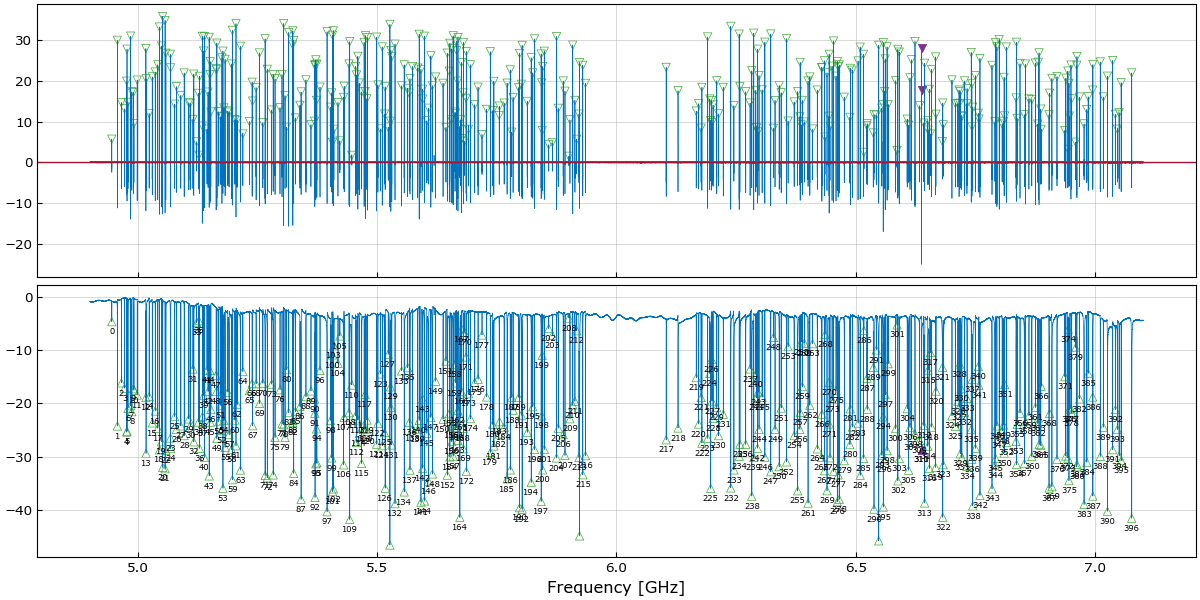

In [4]:
mph = .1
min_df = .1
smoothing_window = 1
smoothing_order = 0
smoothed_dark = smooth_sweep(dark_s21, smoothing_window, smoothing_order)
ds21 = np.diff(smoothed_dark)
smoothed_ds21 = smooth_sweep(ds21, smoothing_window, smoothing_order)
d2s21 = np.diff(smoothed_ds21)

s21 = -(dark_s21-np.amax(dark_s21))
init_locs, props = find_peaks(s21, height=0, prominence=1.5)
init_locs = np.insert(init_locs, 208, 32028)
heights = d2s21[init_locs-1]
# init_locs += 1
init_locs, unique_mask = track_tones(smoothed_dark, init_locs)
# unique_mask[414] = 0

init_f0s = freqs[init_locs]
s21_mins = smoothed_dark[init_locs]

# BEGIN:
too_close_mask = np.zeros(init_f0s.shape, dtype=bool)
for i in range(len(init_f0s) - 1):
    if np.abs(init_f0s[i] - init_f0s[i + 1]) < min_df*1e-3 and (unique_mask[i] and unique_mask[i + 1]):
        too_close_mask[i + 1] = True
        too_close_mask[i] = True

        # if s21_mins[i] < s21_mins[i + 1]:
        #     too_close_mask[i + 1] = True
        # else:
        #     too_close_mask[i] = True

fig, ax = plt.subplot_mosaic('a;b', sharex=True, figsize=(12, 6), constrained_layout=True)
ax['a'].plot(freqs[:-2], d2s21, lw=.5)
ax['b'].plot(freqs, smoothed_dark, lw=.5)
ax['a'].axhline(mph, c='r')
mask = ~too_close_mask & unique_mask
ax['a'].scatter(freqs[init_locs[mask]-1], heights[mask], marker='v', c='None', edgecolor='g')
ax['b'].scatter(init_f0s[mask], s21_mins[mask], marker='^', c='None', edgecolor='g')
ax['a'].scatter(freqs[init_locs[too_close_mask]], heights[too_close_mask], marker='v', c='p', edgecolor='p')
ax['b'].scatter(init_f0s[too_close_mask], s21_mins[too_close_mask], marker='^', c='p', edgecolor='p')
ax['a'].scatter(freqs[init_locs[~unique_mask]], heights[~unique_mask], marker='v', c='r', edgecolor='r')
ax['b'].scatter(init_f0s[~unique_mask], s21_mins[~unique_mask], marker='^', c='r', edgecolor='r')
for i, loc in enumerate(init_locs):
    ax['b'].annotate(f'{i}', (init_f0s[i], s21_mins[i]-5), textcoords="offset points", xytext=(0,10), ha='center', fontsize=6)
ax['b'].set_xlabel('Frequency [GHz]')
print('Total: ', len(init_locs))
too_close = np.argwhere(too_close_mask).flatten().tolist()
unique = np.argwhere(~unique_mask).flatten().tolist()
print('Too close, within', min_df, 'MHz: ', len(init_locs[too_close_mask]), ', ids: ', too_close)
print('Overlapping: ', len(init_locs[~unique_mask]), ', ids: ', unique)

Mean prominence:  17.641635121843642
total:  397
nr doubles:  70
doubles:  [0, 7, 13, 15, 17, 19, 24, 28, 30, 52, 55, 60, 62, 70, 72, 82, 84, 95, 111, 113, 119, 126, 128, 148, 160, 162, 169, 173, 179, 181, 185, 188, 190, 198, 204, 206, 211, 213, 221, 225, 232, 234, 236, 239, 247, 252, 262, 269, 280, 285, 287, 292, 296, 298, 308, 311, 313, 316, 325, 330, 332, 334, 339, 345, 354, 367, 370, 372, 376, 378]
too_close:  [310, 311]
not unique:  [  0  48  10 154  33 161  39 250 167  36 165  31 169 199 190  30 157   4
 148  45  53  42 380 255 168  40 253 242 216 208 172  35 209 215  32 173
 194 184  38   7 158 341 160 163  49 248 382 254 246 171 249 212 220 197
 191 206 174  25 137  13 147  44 384 339 389 251 374 335 378 240 219 226
 262 210 221 189 187  46  54 344 252 377 337 388 256 247 261 259 273 243
 225 202 193  29 159   5 146  56 333 387 343 395 332 379 365 383 245 258
 224 264 211 223 198 183  58 151  41 340 164 352 327 385 364 391 257 301
 369 260 244 195 203 175  24 102  12 143 121 14

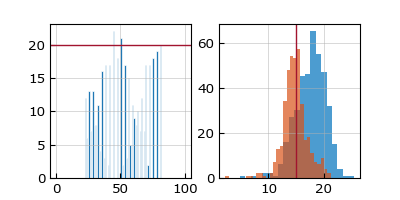

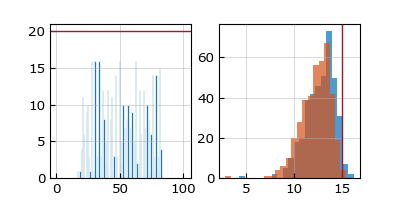

In [112]:
mask = unique_mask
mask = np.ones(init_locs.shape, dtype=bool)
locs = init_locs[mask]
f0s = init_f0s[mask]

ds21s_rows = readout_tones(locs, s21s_rows, dark_s21, smoothing_window, smoothing_order)
ds21s_cols = readout_tones(locs, s21s_cols, dark_s21, smoothing_window, smoothing_order)

mpp = 15
rows, maxproms, secproms, doubles, ds21s_rows = get_pos(ds21s_rows, mpp, deg=3)
print('doubles: ', doubles)
print('too_close: ',too_close)
print('not unique: ',unique)
doubles = [25]
cols, maxproms_cols, secproms_cols, xdoubles, ds21s_cols = get_pos(ds21s_cols, mpp, deg=3)

rows[310] = 62
cols[310] = 50
rows[208] = 25
cols[208] = 60
rows[315] = 59
cols[315] = 55
rows[119] = 69
# doubles = add_kids([], doubles)
# doubles = del_kids(doubles, [393])


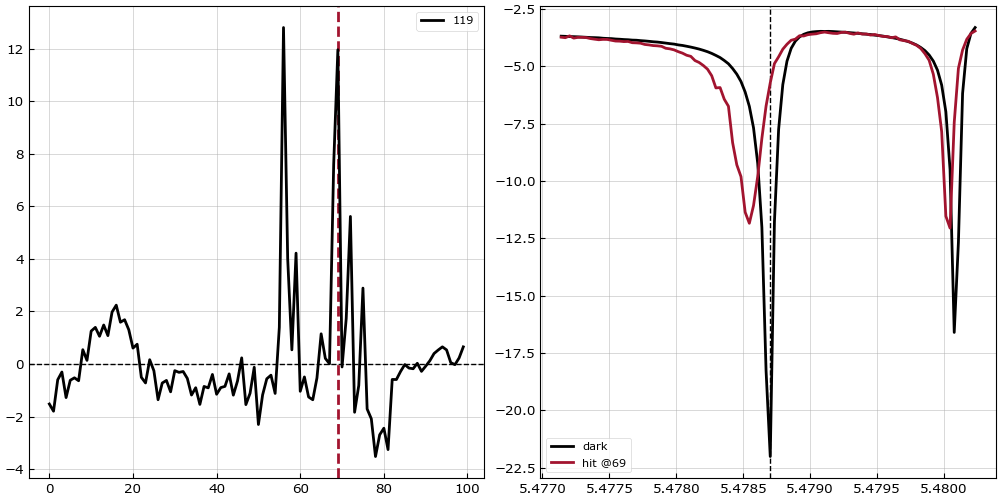

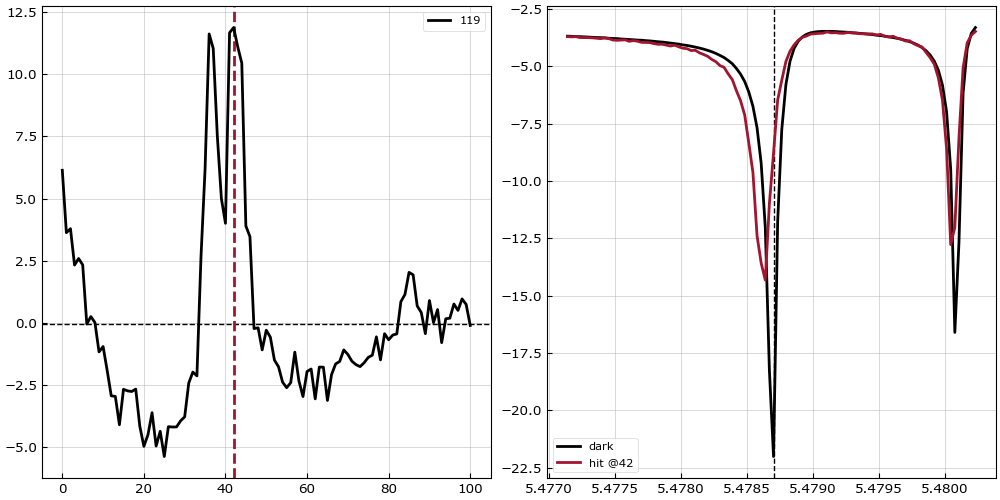

In [113]:
kid = 119
# 1014, 1002, 999, 923, 886, 882, 688, (884), 814, 799, 722, (746), 741, 926
plot_dipshit(s21s_rows, ds21s_rows, rows, [kid], [])
plot_dipshit(s21s_cols, ds21s_cols, cols, [kid], [])


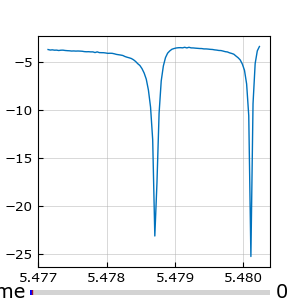

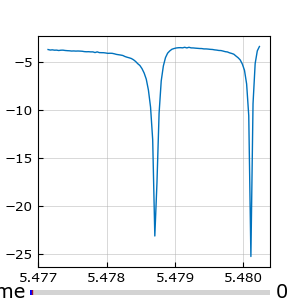

In [114]:
kid = 119
plot_dip_with_slider(s21s_rows, kid, bw=50)
plot_dip_with_slider(s21s_cols, kid)
# plt.show()

In [115]:
stacked = np.vstack((rows, cols)).T
# Find unique rows and their counts
unique_rows, indices, counts = np.unique(stacked, axis=0, return_index=True, return_counts=True)

# Identify non-unique rows
non_unique_mask = counts > 1
non_unique_rows = unique_rows[non_unique_mask]

# Find indices of all non-unique rows in the original array
non_unique_indices = np.where(np.isin(stacked, non_unique_rows).all(axis=1))[0]
# Create a boolean mask for non-unique indices
mask = np.zeros(stacked.shape[0], dtype=bool)
mask[non_unique_indices] = True
print(non_unique_indices)

[ 14  15  31  60  62  66  68  70  72  75  76  80  82  83  85  86  88  89
  92  93  97  98 101 104 105 106 108 110 111 113 114 115 116 120 121 122
 123 124 126 128 129 130 131 138 139 140 142 143 144 145 149 153 155 158
 163 169 171 182 190 193 196 199 201 211 213 214 223 224 225 227 228 234
 239 241 243 245 246 254 256 258 259 261 263 264 265 267 268 269 273 274
 275 276 277 278 279 283 284 287 288 290 291 293 294 296 297 298 303 310
 311 312 313 316 318 319 321 323 324 326 328 329 333 334 338 341 342 345
 347 348 351 353 354 357 358 359 361 362 363 365 366 367 368 370 373 375
 376 379 381 383 386 387 388 390 392 395 396]


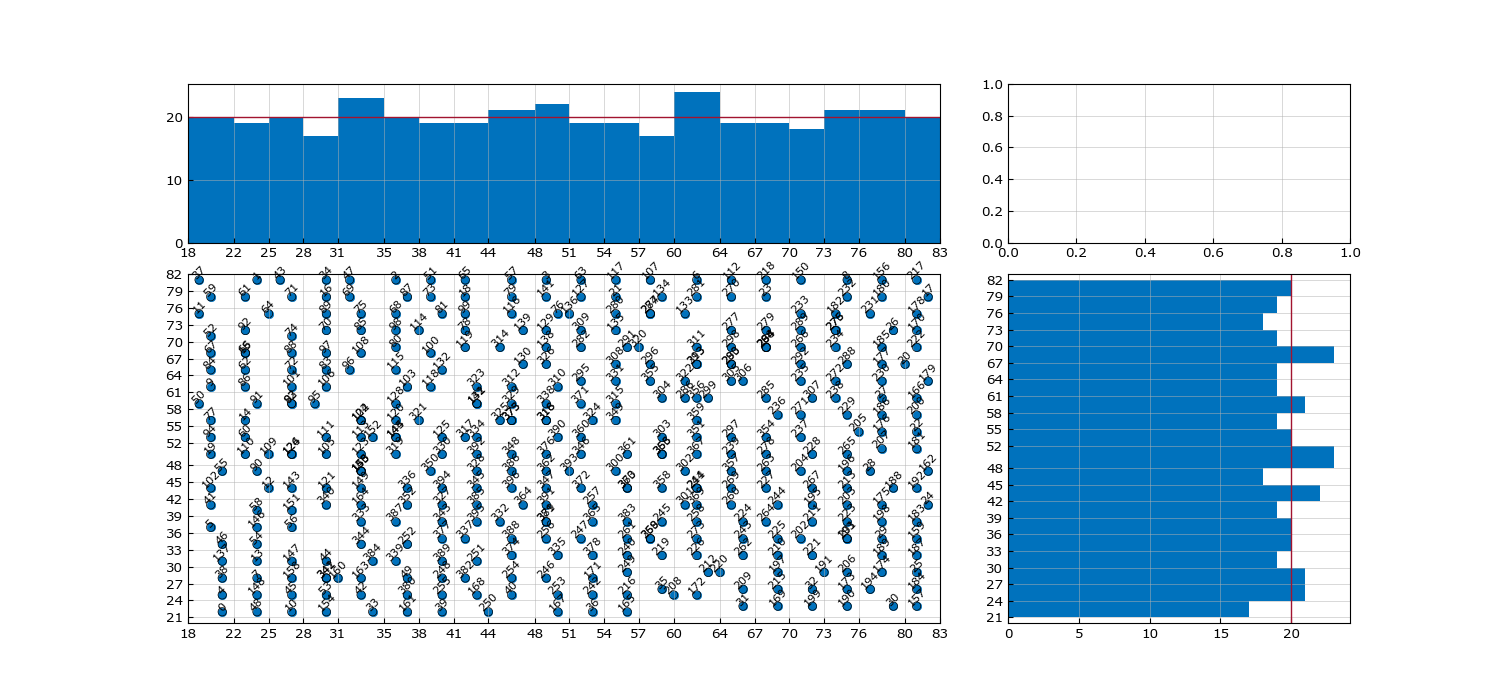

In [116]:
fig, axes = plt.subplot_mosaic('ccd;aab;aab', figsize=(15,7))
ax = axes['a']
unique = np.unique(np.vstack((rows, cols)), axis=1, return_index=True)[1]
ax.scatter(cols, rows, color='b')
ax.scatter(cols, rows, color='None', edgecolors='k')
for i, (col, row) in enumerate(zip(cols, rows)):
    ax.annotate(f'{i}', (col, row), textcoords="offset points", xytext=(0,0), ha='center', fontsize=8, rotation=45)
vedges = np.array([21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 52, 55, 58, 61, 64, 67, 70, 73, 76, 79, 82])
hedges = np.array([18, 22, 25, 28, 31, 35, 38, 41, 44, 48, 51, 54, 57, 60, 64, 67, 70, 73, 76, 80, 83])
ax.set_yticks(vedges)
ax.set_xticks(hedges)
ax.set_ylim(20, 82)
ax.set_xlim(18, 83)
ax = axes['b']
ax.hist(rows, bins=vedges, orientation='horizontal')
ax.set_yticks(vedges)
ax.set_ylim(20, 83)
ax.axvline(20, color='r')
ax = axes['c']
ax.hist(cols, bins=hedges, orientation='vertical')
ax.set_xticks(hedges)
ax.set_xlim(18, 83)
ax.axhline(20, color='r')


In [117]:
rows_corr = copy(rows)
for i, row in enumerate(rows):
    rows_corr[i] = np.where(np.diff(np.sign(row-vedges)))[0][0]
cols_corr = copy(cols)
for i, col in enumerate(cols):
    cols_corr[i] = np.where(np.diff(np.sign(col-hedges)))[0][0]

kids = np.empty((nr_rows, nr_cols))
kids[:] = np.nan
for i in range(len(rows)):
    y = int(rows_corr[i])
    x = int(cols_corr[i])
    if np.isnan(kids[y, x]) and kids[y, x]!=-1:
        kids[y, x] = i
    else:
        print('Collision at: ', y, x)
        kids[y, x] = -1
kids[kids==-1] = np.nan

Collision at:  15 1
Collision at:  12 2
Collision at:  9 1
Collision at:  16 5
Collision at:  11 4
Collision at:  9 2
Collision at:  17 9
Collision at:  12 7
Collision at:  10 5
Collision at:  10 4
Collision at:  8 4
Collision at:  8 4
Collision at:  14 18
Collision at:  4 17
Collision at:  1 12
Collision at:  2 13
Collision at:  7 13
Collision at:  16 17
Collision at:  15 15
Collision at:  17 12
Collision at:  14 14
Collision at:  15 15
Collision at:  12 13
Collision at:  13 14
Collision at:  14 13
Collision at:  11 9
Collision at:  15 11
Collision at:  11 5
Collision at:  10 7
Collision at:  2 3
Collision at:  2 3
Collision at:  12 13
Collision at:  9 12
Collision at:  4 12
Collision at:  6 13
Collision at:  7 11
Collision at:  11 8
Collision at:  11 8
Collision at:  5 9
Collision at:  8 9


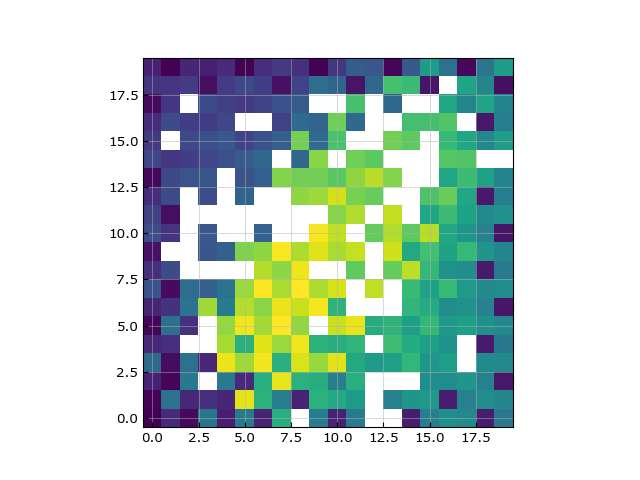

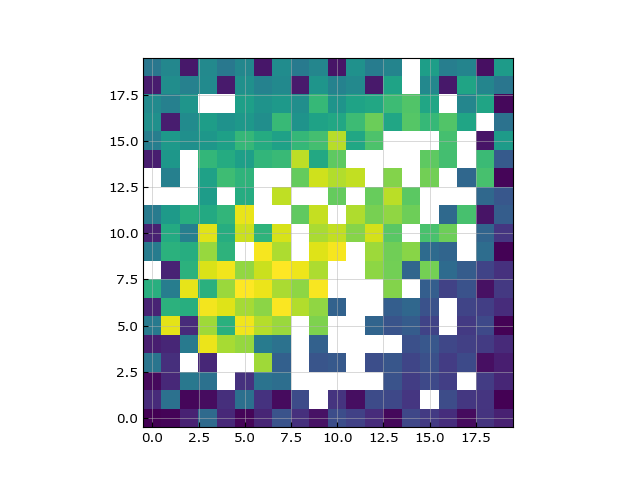

In [118]:
fig, ax = plt.subplots()
ax.imshow(kids, origin='lower')
fig, ax = plt.subplots()
kids = kids.T
ax.imshow(kids, origin='lower')


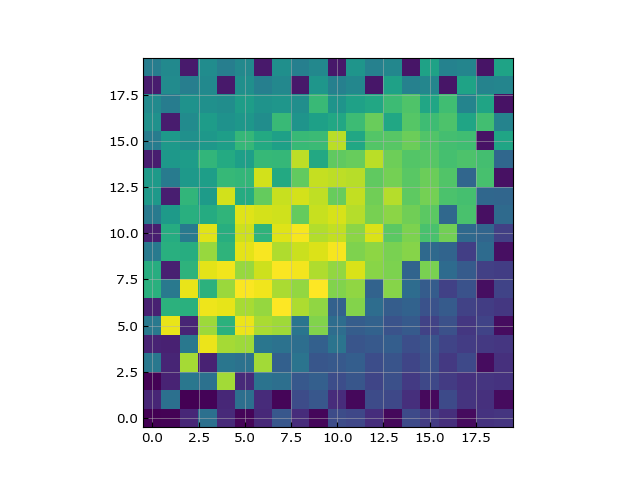

In [119]:
fig, ax = plt.subplots()
ax.imshow(kid_id_board, origin='lower')

In [120]:
design_f0s = master['design']['f0']
master['measured'] = {}
master['measured']['f0'] = np.empty(nr_rows*nr_cols)
master['measured']['f0'][:] = np.nan
for i, row in enumerate(kid_id_board):
    for j, idx in enumerate(row):
        meas_idx = kids[i, j]
        if ~np.isnan(meas_idx):
            meas_f = f0s[int(meas_idx)]
            master['measured']['f0'][idx] = meas_f
design = master['design']['f0']
meas = master['measured']['f0']
nanmask = np.isnan(meas) + np.isnan(design)
sort_idx = np.argsort(meas[~nanmask])
inverse_sort_idx = np.argsort(sort_idx)

          2
-0.04663 x + 1.668 x - 1.44
scatter = 0.490%
yield = 80.500%


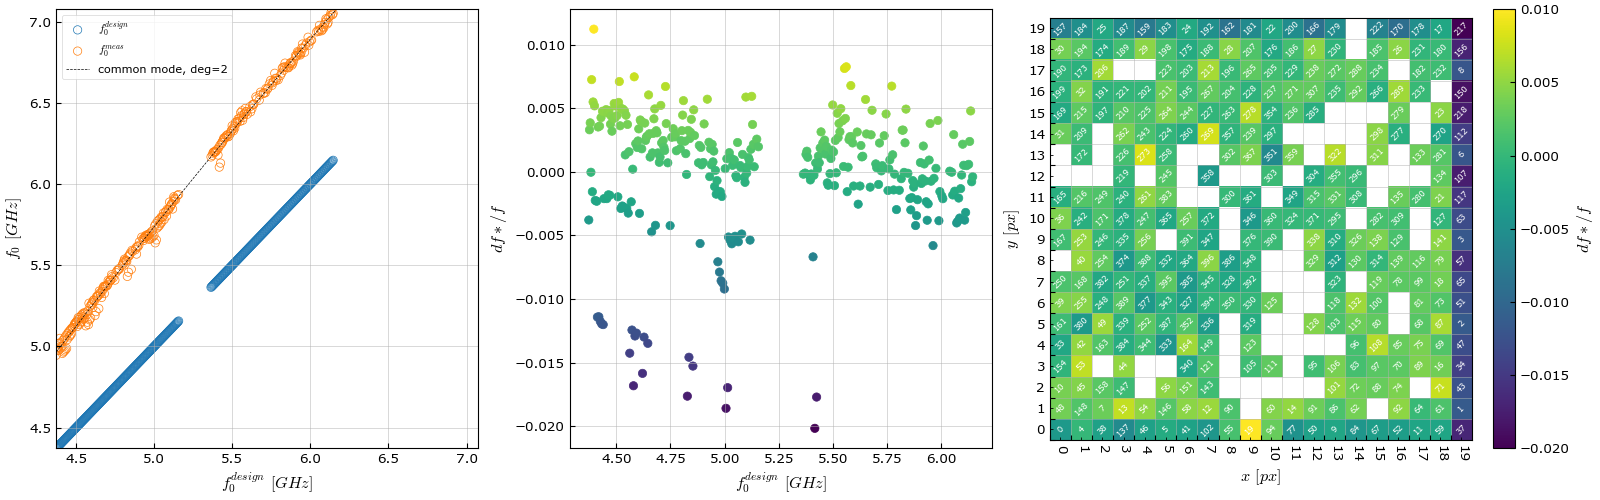

In [121]:
df_f, df_f_map = plot_scatter(2, annotate=True, clim=[-0.02, 0.01], edges=True)

In [132]:
maps = image(ds21s_rows)

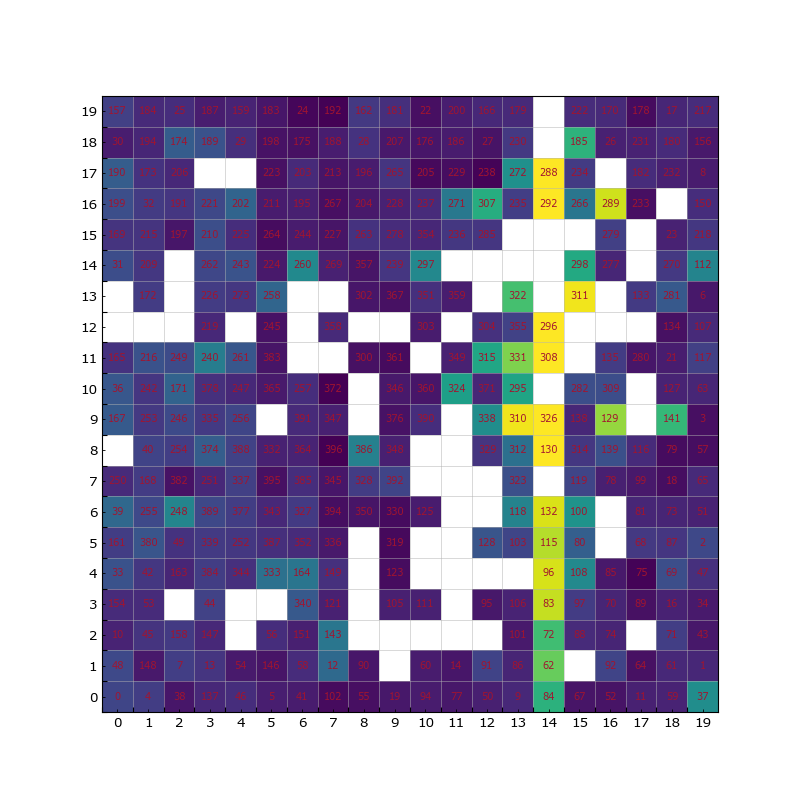

In [141]:
_ = plot_image(maps[:,:, 66])

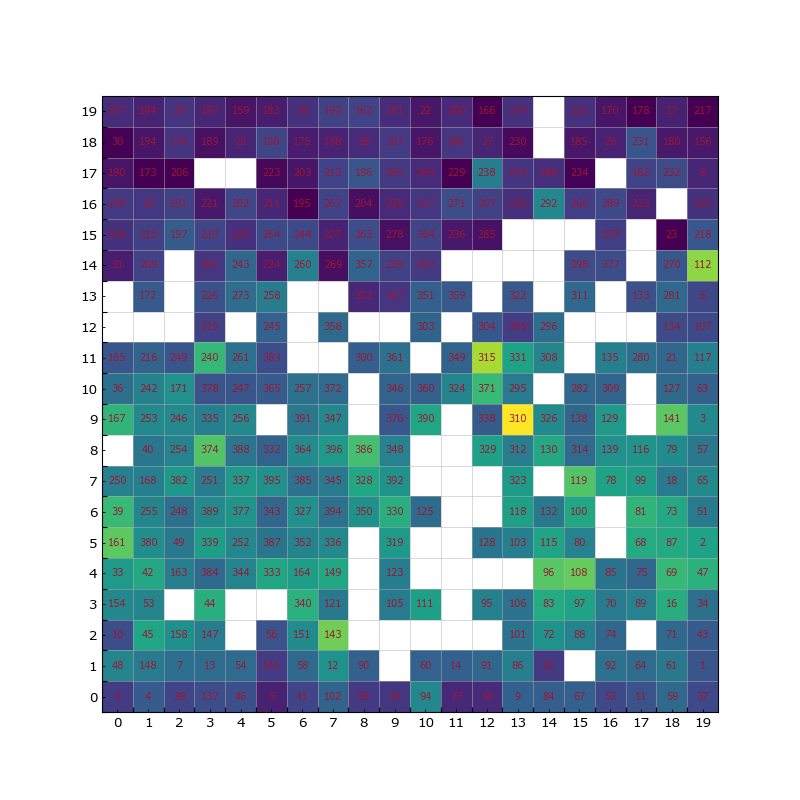

In [131]:
anim = animate_image(maps)
plt.show()